# Describe maps — interactive viewer

Replay the precomputed TAM annotations written by `tamart.experiments.describe`.
No model inference is run here — maps, tokens and the processed image are read
straight from `data/datasets/wikiart_most_viewed/describe/<stem>/`.

Pick an image from the dropdown, then click below the painting to see activation
maps. Two modes:

- **Token mode** (default): click individual generated tokens to overlay their
  (mean) activation maps.
- **Span mode**: tick *Span mode* to use the classified expressions from
  `tamart.experiments.classify` (`classify/<stem>/classification.json`). The
  full caption is shown with the multi-token spans highlighted by category;
  click a single span to see the mean map over its tokens.

Tweak colormap / alpha / value range to inspect what each map contains.

In [1]:
import tamart  # must come before any transformers import (sets HF_HOME)
from tamart.tam import TAMExplainer

explainer = TAMExplainer()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

## Pick a precomputed annotation

The dropdown lists every subfolder under `describe/` that has an `answer.json`.

In [2]:
from pathlib import Path
import ipywidgets as widgets

DESCRIBE_DIR = Path("../data/datasets/wikiart_most_viewed/describe")
CLASSIFY_DIR = Path("../data/datasets/wikiart_most_viewed/classify")

folders = sorted(
    p for p in DESCRIBE_DIR.iterdir()
    if (p / "answer.json").exists()
)
assert folders, f"No precomputed annotations found in {DESCRIBE_DIR.resolve()}"

folder_dd = widgets.Dropdown(
    options=[(p.name, p) for p in folders],
    description="Image:",
    layout=widgets.Layout(width="60%"),
)
span_mode = widgets.Checkbox(
    value=False,
    description="Span mode (use classify/ expressions)",
    indent=False,
)
widgets.VBox([folder_dd, span_mode])

## Interactive viewer

Run the cell below after choosing an image above. Re-run it whenever you change
the dropdown selection to load a different annotation.

In [3]:
classify_folder = CLASSIFY_DIR / folder_dd.value.name
use_spans = span_mode.value and (classify_folder / "classification.json").exists()
if span_mode.value and not use_spans:
    print(f"No classification.json under {classify_folder} — falling back to token mode.")

result = explainer.explain_interactive_precomputed(
    folder_dd.value,
    classify_folder=classify_folder if use_spans else None,
)

HTML(value='<b>Generated:</b> This image is a famous painting titled "Mona Lisa," created by the Italian artis…

## Paper figure — span-localized activation maps

Horizontal teaser for the paper. A trimmed excerpt of the *Starry Night* caption
is shown on the left with three spans highlighted — one **META**, one **CVO**,
one **STYLE** — each in its own color. On the right the painting appears twice:
the input, and a copy with the three span activation maps drawn in the matching
colors. The CVO span (`small village or town`) localizes to one region, while
the STYLE/META spans scatter across the canvas — the contrast the figure makes.
Output is a vector PDF in `notebooks/figs/`.

/home/nifane/tmp/ipykernel_1704194/1595951135.py:63: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = fig.add_axes([x0_in / FIG_W, title_h / FIG_H, pw / FIG_W, ph / FIG_H])
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved figs/starry_night_spans.pdf


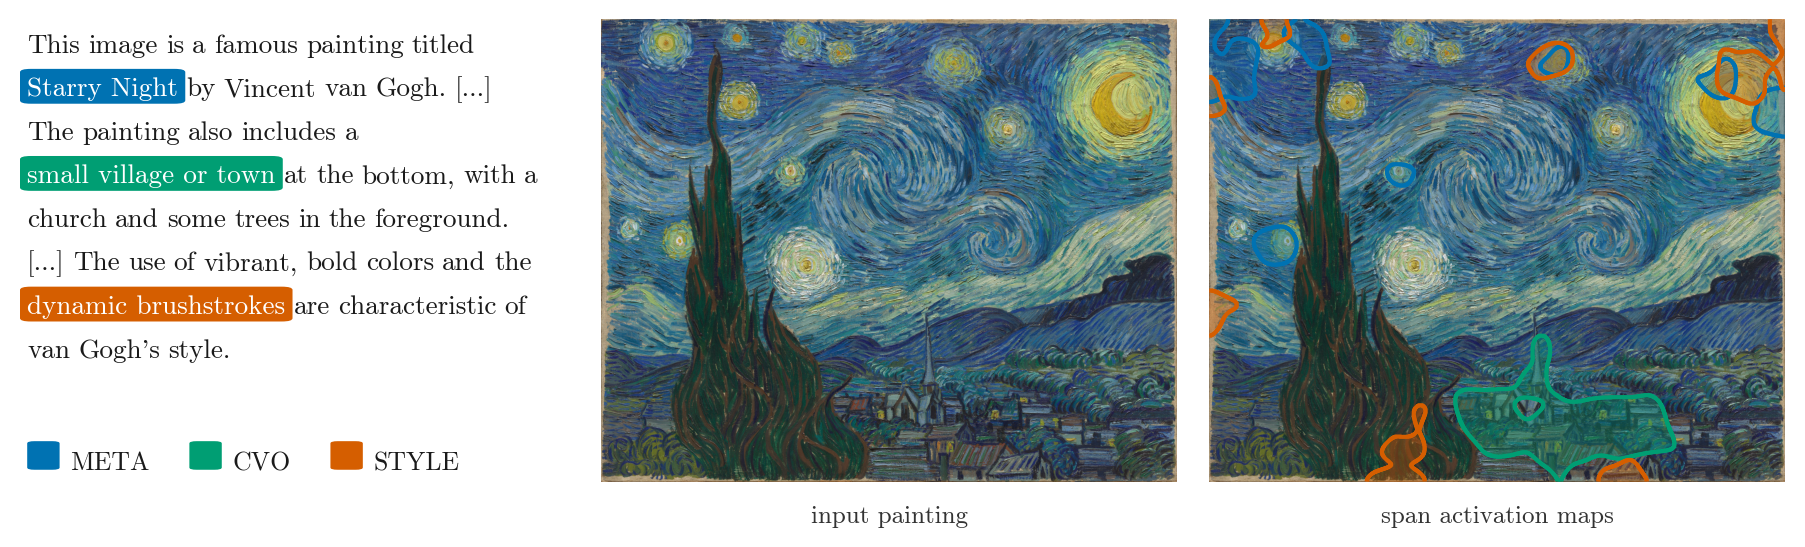

In [4]:
# Self-contained: reads the precomputed describe/classify files directly, so it
# runs without the model loaded. Horizontal teaser: a trimmed caption on the
# left with one META / one CVO / one STYLE span highlighted, then the painting
# twice on the right (input vs. the three span activation maps in matching
# colours). Saved as a vector PDF under notebooks/figs/.
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from scipy.ndimage import zoom, gaussian_filter, label
from PIL import Image
from safetensors.numpy import load_file

# LaTeX-like (Computer Modern) typography, embedded as real text in the PDF.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["cmr10", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
})

ROOT = Path("../data/datasets/wikiart_most_viewed")
STEM = "0002_the-starry-night-1889"
FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)

tensors = load_file(str(ROOT / "describe" / STEM / "maps.safetensors"))
spans_all = json.load(open(ROOT / "classify" / STEM / "classification.json"))
proc_img = np.asarray(Image.open(ROOT / "describe" / STEM / "proc_img.png").convert("RGB"))
H, W = proc_img.shape[:2]
by_word = {s["word"]: s for s in spans_all}

# One span per category, each with its own colourblind-friendly colour.
FEATURES = [
    ("Starry Night",          "META",  "#0072B2"),  # blue   -> diffuse / global
    ("small village or town", "CVO",   "#009E73"),  # green  -> localized region
    ("dynamic brushstrokes",  "STYLE", "#D55E00"),  # orange -> spread over canvas
]

def span_map(word, smooth=1.1):
    """Mean activation map over a span's tokens, upscaled and smoothed to [0, 1]."""
    span = by_word[word]
    m = np.mean([tensors[str(t)] for t in span["tokens"]], axis=0).astype(np.float32)
    m = zoom(m, (H / m.shape[0], W / m.shape[1]), order=1)
    m = gaussian_filter(m, sigma=smooth * min(H, W) / 100.0)
    return (m - m.min()) / (m.max() - m.min() + 1e-9)

# --------------------------------------------------------------- horizontal layout
aspect = W / H
FIG_W = 9.0
lm, cw, cgap, g, rm = 0.08, 2.7, 0.22, 0.16, 0.08   # margins / caption width (inches)
top, title_h = 0.10, 0.28
pw = (FIG_W - lm - cw - cgap - g - rm) / 2.0         # painting width (two side by side)
ph = pw / aspect
FIG_H = top + ph + title_h

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=200)

def painting_ax(x0_in, base):
    ax = fig.add_axes([x0_in / FIG_W, title_h / FIG_H, pw / FIG_W, ph / FIG_H])
    ax.imshow(base); ax.set_xlim(0, W); ax.set_ylim(H, 0)
    ax.set_xticks([]); ax.set_yticks([])   # keep spines -> thin panel border
    return ax

# Dim + desaturate the right painting so the coloured span maps stand out (a
# translucent tint over the full-colour image washes the regions out).
_gray = proc_img.mean(axis=2, keepdims=True)
_dim = np.clip((0.5 * proc_img + 0.5 * _gray) * 0.72, 0, 255).astype(np.uint8)

x_orig = lm + cw + cgap
x_maps = x_orig + pw + g
ax_orig = painting_ax(x_orig, proc_img)
ax_maps = painting_ax(x_maps, _dim)

# overlay the three span maps on the right painting, each in its own colour
X, Y = np.arange(W), np.arange(H)
LEVEL, MIN_AREA = 0.5, 0.0015 * H * W       # keep scattered blobs (shows diffuse spans)
for word, _cat, color in FEATURES:
    m = span_map(word)
    lab, n = label(m >= LEVEL)
    keep = np.zeros_like(m, dtype=bool)
    for k in range(1, n + 1):
        comp = lab == k
        if comp.sum() >= MIN_AREA:
            keep |= comp
    m = np.where(keep, m, 0.0)
    ax_maps.contourf(X, Y, m, levels=[LEVEL, 1.0], colors=[color], alpha=0.55, zorder=3)
    ax_maps.contour(X, Y, m, levels=[LEVEL], colors=[color], linewidths=2.0, zorder=4)

for ax, lab_txt in ((ax_orig, "input painting"), (ax_maps, "span activation maps")):
    ax.text(0.5, -0.05, lab_txt, transform=ax.transAxes, ha="center", va="top",
            fontsize=9, color="#333333")

# ------------------------------------------------------------- caption + legend
# Real model output, trimmed to the three sentences holding our spans ([...] = cut).
F1 = "This image is a famous painting titled Starry Night by Vincent van Gogh."
F2 = ("The painting also includes a small village or town at the bottom, with a "
      "church and some trees in the foreground.")
F3 = ("The use of vibrant, bold colors and the dynamic brushstrokes are "
      "characteristic of van Gogh's style.")
TEXT = f"{F1} [...] {F2} [...] {F3}"
PHRASES = [(w, c) for w, _cat, c in FEATURES]

def build_chunks(text, phrases):
    """Split text into (token, colour) chunks; highlighted phrases stay whole."""
    out, i = [], 0
    while i < len(text):
        hit = next(((p, c) for p, c in phrases if text.startswith(p, i)), None)
        if hit:
            out.append(hit); i += len(hit[0])
        else:
            j = i
            while j < len(text) and not any(text.startswith(p, j) for p, _ in phrases):
                j += 1
            out.extend((w, None) for w in text[i:j].split(" ") if w)
            i = j
    return out

chunks = build_chunks(TEXT, PHRASES)

fig.canvas.draw()
renderer = fig.canvas.get_renderer()
FS = 9.8
pt2fy = (1.0 / 72.0) / FIG_H        # font points -> figure-fraction (vertical)
line_h = FS * 1.6 * pt2fy
box_h = FS * 1.28 * pt2fy
box_dy = FS * 0.30 * pt2fy
x_left = (lm + 0.05) / FIG_W
x_right = (lm + cw - 0.05) / FIG_W
y_top = (title_h + ph) / FIG_H - FS * 1.2 * pt2fy
space_w = (FS * 0.30 / 72.0) / FIG_W

def text_w(s):
    t = fig.text(0, 0, s, fontsize=FS); fig.canvas.draw()
    w = t.get_window_extent(renderer).width / (FIG_W * fig.dpi); t.remove()
    return w

x, y = x_left, y_top
for s, col in chunks:                # greedy word-wrap with highlight boxes
    w = text_w(s)
    if x + w > x_right:
        x = x_left; y -= line_h
    if col:
        px = 0.004
        fig.add_artist(FancyBboxPatch(
            (x - px, y - box_dy), w + 2 * px, box_h,
            boxstyle="round,pad=0.0,rounding_size=0.006",
            transform=fig.transFigure, facecolor=col, edgecolor="none", zorder=1))
        fig.text(x, y, s, fontsize=FS, color="white", zorder=2, va="baseline")
    else:
        fig.text(x, y, s, fontsize=FS, color="#1a1a1a", zorder=2, va="baseline")
    x += w + space_w

# colour -> category legend, pinned to the bottom of the caption column
ly = (title_h + 0.06) / FIG_H
lx = x_left
for word, cat, color in FEATURES:
    fig.add_artist(FancyBboxPatch(
        (lx, ly), 0.018, FS * 1.05 * pt2fy,
        boxstyle="round,pad=0.0,rounding_size=0.004",
        transform=fig.transFigure, facecolor=color, edgecolor="none"))
    t = fig.text(lx + 0.024, ly, cat, fontsize=FS - 0.5, va="baseline", color="#1a1a1a")
    fig.canvas.draw()
    lx += 0.024 + t.get_window_extent(renderer).width / (FIG_W * fig.dpi) + 0.022

out = FIGS / "starry_night_spans.pdf"
fig.savefig(out, bbox_inches="tight")
fig.savefig(out.with_suffix(".png"), bbox_inches="tight", dpi=200)
print("saved", out)
plt.show()